In [ ]:
''' Title: Recommendation System
 BUILD A RECOMMENDATION SYSTEM USING COLLABORATIVE FILTERING OR MATRIX FACTORIZATION TECHNIQUES.
    Expected Output 
         A NOTEBOOK OR APP SHOWCASING RECOMMENDATION RESULTS AND EVALUATION METRICS.'''

In [ ]:
# IMPORTING REQUIRED LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [ ]:
# LOAD DATASET
df = pd.read_csv("survey.csv")   
df.head()       # Display first 5 rows

,Timestamp,Age,Gender,Country,state,self_employed,family_history,treatment,work_interfere,no_employees,...,leave,mental_health_consequence,phys_health_consequence,coworkers,supervisor,mental_health_interview,phys_health_interview,mental_vs_physical,obs_consequence,comments
0,2014-08-27 11:29:31,37,Female,United States,IL,NaN,No,Yes,Often,6-25,...,Somewhat easy,No,No,Some of them,Yes,No,Maybe,Yes,No,NaN
1,2014-08-27 11:29:37,44,M,United States,IN,NaN,No,No,Rarely,More than 1000,...,Don't know,Maybe,No,No,No,No,No,Don't know,No,NaN
2,2014-08-27 11:29:44,32,Male,Canada,NaN,NaN,No,No,Rarely,6-25,...,Somewhat difficult,No,No,Yes,Yes,Yes,Yes,No,No,NaN
3,2014-08-27 11:29:46,31,Male,United Kingdom,NaN,NaN,Yes,Yes,Often,26-100,...,Somewhat difficult,Yes,Yes,Some of them,No,Maybe,Maybe,No,Yes,NaN
4,2014-08-27 11:30:22,31,Male,United States,TX,NaN,No,No,Never,100-500,...,Don't know,No,No,Some of them,Yes,Yes,Yes,Don't know,No,NaN


In [ ]:
# SELECTING SERVICE COLUMNS

#Represent different mental health support services
service_columns = [
    "benefits",
    "care_options",
    "wellness_program",
    "seek_help",
    "anonymity",
    "leave"
]

df_services = df[service_columns].copy()  # Creating a new dataframe with only selected services
df_services.head()

,benefits,care_options,wellness_program,seek_help,anonymity,leave
0,Yes,Not sure,No,Yes,Yes,Somewhat easy
1,Don't know,No,Don't know,Don't know,Don't know,Don't know
2,No,No,No,No,Don't know,Somewhat difficult
3,No,Yes,No,No,No,Somewhat difficult
4,Yes,No,Don't know,Don't know,Don't know,Don't know


In [ ]:
# CONVERTING TEXT RESPONSES TO RATINGS

# Mapping categorical answers into numeric ratings (1–5 scale)
rating_map = {
    "Yes": 5,
    "No": 1,
    "Somewhat": 3,
    "Don't know": 2,
    "Not sure": 2,
    "Very easy": 5,
    "Easy": 4,
    "Difficult": 2,
    "Very difficult": 1
}

for col in service_columns:
    df_services[col] = df_services[col].map(rating_map)

df_services = df_services.fillna(2)   # Replace missing values with neutral rating (2)
df_services.head()

,benefits,care_options,wellness_program,seek_help,anonymity,leave
0,5,2,1,5,5,2.0
1,2,1,2,2,2,2.0
2,1,1,1,1,2,2.0
3,1,5,1,1,1,2.0
4,5,1,2,2,2,2.0


In [ ]:
# CREATING USER-ITEM MATRIX
df_services["userID"] = df_services.index       # Assigning a unique user ID (using row index)

user_item_matrix = df_services.set_index("userID")    # Setting userID as index to create user-item interaction matrix
user_item_matrix.head()

,benefits,care_options,wellness_program,seek_help,anonymity,leave
userID,,,,,,
0,5,2,1,5,5,2.0
1,2,1,2,2,2,2.0
2,1,1,1,1,2,2.0
3,1,5,1,1,1,2.0
4,5,1,2,2,2,2.0


In [ ]:
# APPLYING MATRIX FACTORIZATION (SVD)
svd = TruncatedSVD(n_components=3, random_state=42)  # Using 3 latent factors for dimensionality reduction
latent_matrix = svd.fit_transform(user_item_matrix)  # Transforming the user-item matrix into latent representation

reconstructed_matrix = np.dot(latent_matrix, svd.components_)     # Reconstructing the matrix from latent factors


# Converting reconstructed matrix into DataFrame
reconstructed_df = pd.DataFrame(
    reconstructed_matrix,
    columns=user_item_matrix.columns,
    index=user_item_matrix.index
)

reconstructed_df.head()

,benefits,care_options,wellness_program,seek_help,anonymity,leave
userID,,,,,,
0,4.281065,2.668730,3.333350,3.593576,3.624662,3.134127
1,2.199680,0.929726,1.837278,1.959635,2.035772,1.965062
2,1.214380,0.939640,0.862653,0.925126,1.990269,2.001747
3,1.841439,4.416812,0.454417,0.621141,2.161101,1.019056
4,3.272635,1.440377,2.741898,2.937961,2.197199,1.891929


In [ ]:
# MODEL EVALUATION (RMSE)
rmse = np.sqrt(mean_squared_error(user_item_matrix, reconstructed_df))  # Calculating Root Mean Squared Error
print("RMSE:", rmse)

RMSE: 0.7875868418768255


In [ ]:
# GENERATING RECOMMENDATIONS
user_id = 5  # Selecting a particular user

original_ratings = user_item_matrix.loc[user_id]
predicted_ratings = reconstructed_df.loc[user_id]   # Getting predicted ratings for this user

recommendations = predicted_ratings.sort_values(ascending=False)  # Sorting services by highest predicted rating

print("Top Recommended Mental Health Services:")
print(recommendations.head(3))

Top Recommended Mental Health Services:
benefits        3.141312
seek_help       2.516014
care_options    2.450200
Name: 5, dtype: float64


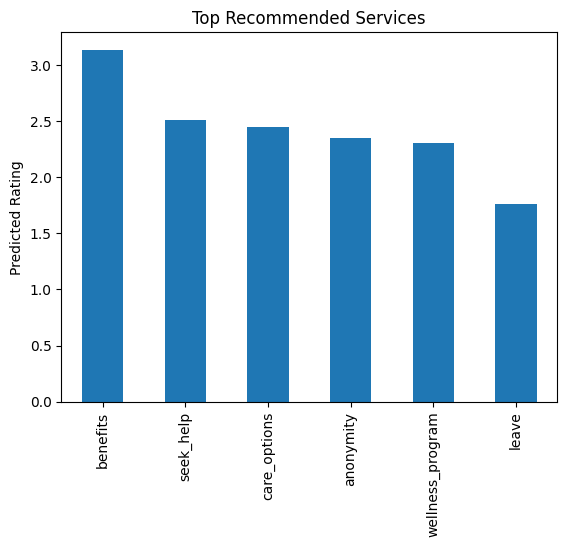

In [ ]:
# VISUALIZING TOP RECOMMENDATIONS
recommendations.head(6).plot(kind='bar')
plt.title("Top Recommended Services")
plt.ylabel("Predicted Rating")
plt.show()


Average Service Ratings:
anonymity           2.841938
benefits            2.839555
care_options        2.660048
leave               2.413026
seek_help           2.082605
wellness_program    1.876886
dtype: float64


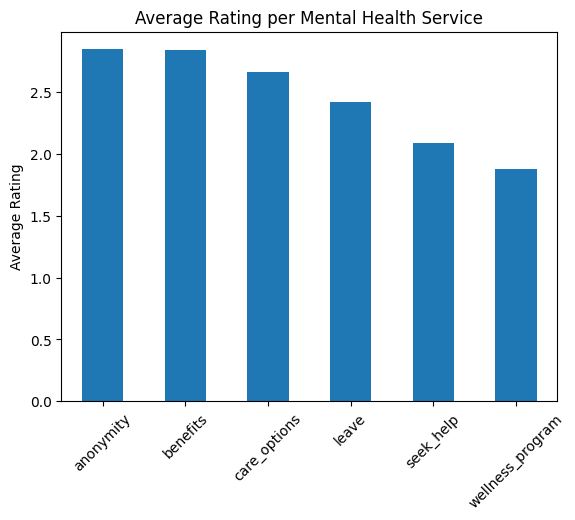

In [ ]:
# SERVICE POPULARITY ANALYSIS

# Average rating per service
avg_service_ratings = user_item_matrix.mean().sort_values(ascending=False)

print("Average Service Ratings:")
print(avg_service_ratings)

# Plot
avg_service_ratings.plot(kind='bar')
plt.title("Average Rating per Mental Health Service")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.show()

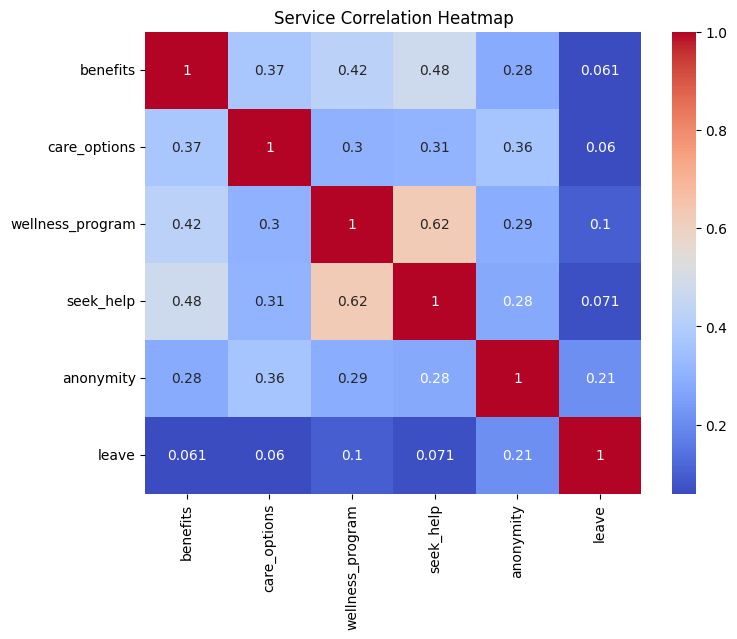

In [ ]:
# SERVICE CORRELATION HEATMAP
import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(user_item_matrix.corr(), 
            annot=True, 
            cmap="coolwarm")

plt.title("Service Correlation Heatmap")
plt.show()

In [ ]:
# EXPLAINED RECOMMENDATIONS

user_id = 5

original_ratings = user_item_matrix.loc[user_id]
predicted_ratings = reconstructed_df.loc[user_id]

recommendations = predicted_ratings.sort_values(ascending=False)

print("Top Recommended Services with Explanation:\n")

for service in recommendations.head(3).index:
    similar_users_avg = user_item_matrix[service].mean()
    
    print(f"{service}")
    print(f"Predicted Rating: {round(predicted_ratings[service],2)}")
    print(f"Reason: Users with similar mental health patterns rated this service highly (Avg rating: {round(similar_users_avg,2)})\n")

Top Recommended Services with Explanation:

benefits
Predicted Rating: 3.14
Reason: Users with similar mental health patterns rated this service highly (Avg rating: 2.84)

seek_help
Predicted Rating: 2.52
Reason: Users with similar mental health patterns rated this service highly (Avg rating: 2.08)

care_options
Predicted Rating: 2.45
Reason: Users with similar mental health patterns rated this service highly (Avg rating: 2.66)



In [ ]:
# BASELINE MODEL COMPARISON


#Predicting average rating for all users
baseline_prediction = np.tile(user_item_matrix.mean(), (len(user_item_matrix), 1))

baseline_rmse = np.sqrt(mean_squared_error(user_item_matrix, baseline_prediction))
svd_rmse = np.sqrt(mean_squared_error(user_item_matrix, reconstructed_matrix))

print("Baseline RMSE:", baseline_rmse)
print("Matrix Factorization RMSE:", svd_rmse)

Baseline RMSE: 1.5343645034014435
Matrix Factorization RMSE: 0.7875868418768255
